# Model 1 - Baseline CNN

From-scratch CNN: 3 conv blocks -> **Flatten** -> Dropout -> softmax. This is
the reference every later model is compared against. Shared preprocessing /
evaluation logic is imported from the `.py` modules so every model notebook
runs the exact same pipeline.

## 1. Setup & imports

Put the shared `.py` folders on the path and import the pipeline: dataset
builder, data loader, the model factory, and the evaluation + plotting helpers.

In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "preprocessing", "label_mapping"))
sys.path.append(os.path.join(os.getcwd(), "preprocessing", "data_loader"))
sys.path.append(os.path.join(os.getcwd(), "model"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "model_metrics"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "plots"))

import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

from label_mapping import build_labeled_dataset
from data_loader import build_train_val_test_generators
from baseline_cnn import build_baseline_cnn
from model_metrics import debug_model, evaluate_model, record_result
from plots import plot_sample_images, plot_misclassified

## 2. Load & label the dataset

Map each Italian folder name to its English label and record a root-relative
path for every image. One row per image (`image_path`, `label_it`, `label_en`).

In [2]:
df = build_labeled_dataset()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26179 entries, 0 to 26178
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  26179 non-null  object
 1   label_it    26179 non-null  object
 2   label_en    26179 non-null  object
dtypes: object(3)
memory usage: 613.7+ KB


## 2b. Explore: sample image per class

Before any modeling, look at the raw data - one random image per class with its
English label. Confirms the labels are sensible and shows the visual variety /
difficulty (e.g. how alike cow, horse and sheep look). This is the brief's
required sample-images visualization.

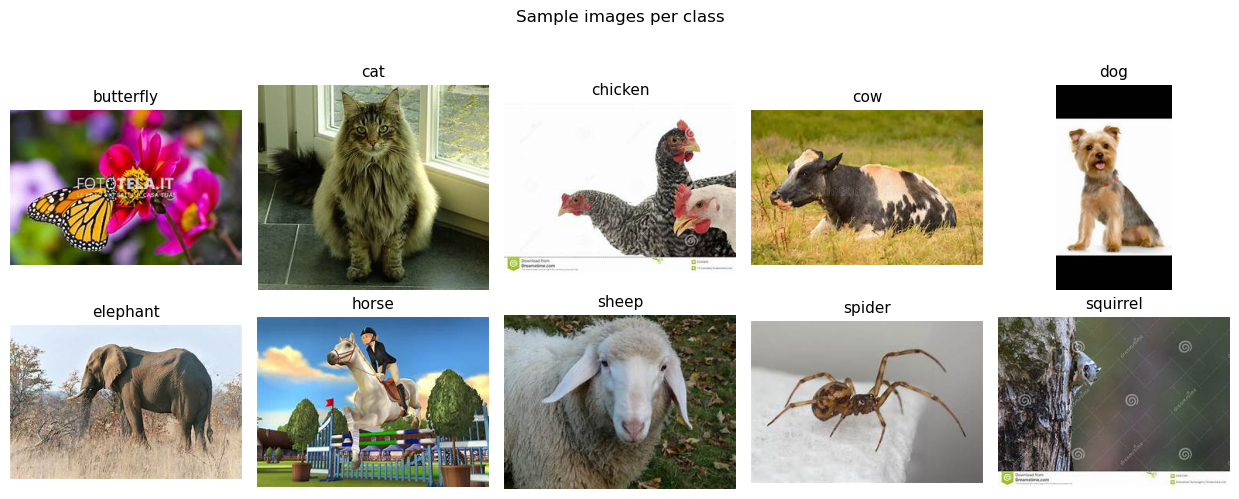

In [3]:
plot_sample_images(df, project_root=os.getcwd())

## 3. Preprocess: split, resize, normalize

Stratified 70/15/15 train/val/test split (seed=42), then resize to 128x128 and
rescale pixels to [0, 1]. Val/test use `shuffle=False` so predictions stay
aligned with labels.

In [4]:
train_generator, val_generator, test_generator = build_train_val_test_generators(
    df, project_root=os.getcwd(), image_size=(128, 128)
)
train_generator.class_indices

Found 18325 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.


{'butterfly': 0,
 'cat': 1,
 'chicken': 2,
 'cow': 3,
 'dog': 4,
 'elephant': 5,
 'horse': 6,
 'sheep': 7,
 'spider': 8,
 'squirrel': 9}

## 4. Build the CNN

Three Conv blocks (32->64->128 filters) -> **Flatten** -> Dropout(0.5) ->
softmax. `input_shape` / `num_classes` are read from the generator so they can't
drift out of sync with the data.

In [5]:
model = build_baseline_cnn(
    input_shape=train_generator.image_shape,
    num_classes=len(train_generator.class_indices),
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       184,330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,338 (1.80 MB)

 Trainable params: 471,338 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train — or load a saved model

If `models_saved/baseline_cnn.keras` already exists it's **loaded** (skips the
15-min retrain); otherwise the model trains with `EarlyStopping` and is saved.
Set `RETRAIN = True` (or delete the file) to force a fresh run. The fit is timed
so `train_time_min` is measured, not hand-typed.

In [6]:
import time
from tensorflow import keras

# Load the saved model if present so a kernel restart doesn't cost a full
# retrain. Delete the file or set RETRAIN=True to train fresh.
MODEL_PATH = "models_saved/baseline_cnn.keras"
RETRAIN = False

if not RETRAIN and os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    history, train_time_min = None, None
    print(f"Loaded {MODEL_PATH} (skipped training).")
else:
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
    start_time = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=[early_stopping],
    )
    train_time_min = round((time.time() - start_time) / 60, 1)
    print(f"Trained in {train_time_min} min.")

Loaded models_saved/baseline_cnn.keras (skipped training).


## 6. Training history

Per-epoch accuracy/loss. `acc_gap` = train - val accuracy; a widening gap is the
tell-tale sign of overfitting (the baseline's grows to ~13%).

In [7]:
# Training history — only when we actually trained this run.
if history is not None:
    history_df = pd.DataFrame(history.history)
    history_df.index.name = "epoch"
    history_df["acc_gap"] = history_df["accuracy"] - history_df["val_accuracy"]
    display(history_df)
else:
    print("Model was loaded from disk — no training history this run.")

Model was loaded from disk — no training history this run.


## 7. Evaluate: per-class report + confusion matrix

Score on the **validation** set (test set held back for the final winner).
Prints per-class precision/recall/F1 and plots the confusion-matrix heatmap.

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
              precision    recall  f1-score   support

   butterfly       0.89      0.68      0.77       317
         cat       0.61      0.43      0.50       250
     chicken       0.86      0.78      0.82       464
         cow       0.54      0.57      0.56       280
         dog       0.62      0.79      0.70       730
    elephant       0.65      0.67      0.66       217
       horse       0.69      0.63      0.66       393
       sheep       0.60      0.59      0.59       273
      spider       0.83      0.83      0.83       723
    squirrel       0.59      0.60      0.59       280

    accuracy                           0.70      3927
   macro avg       0.69      0.66      0.67      3927
weighted avg       0.71      0.70      0.70      3927



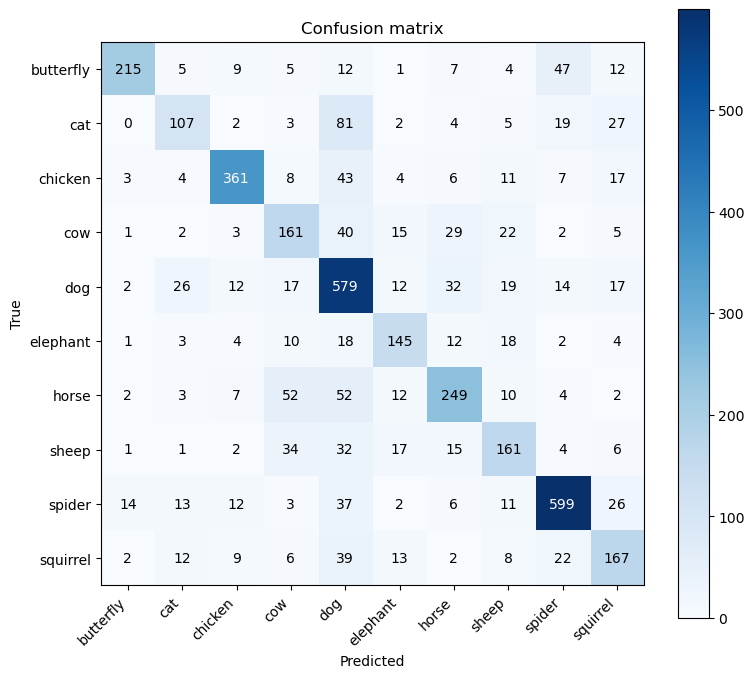

,butterfly,cat,chicken,cow,dog,elephant,horse,sheep,spider,squirrel
butterfly,215,5,9,5,12,1,7,4,47,12
cat,0,107,2,3,81,2,4,5,19,27
chicken,3,4,361,8,43,4,6,11,7,17
cow,1,2,3,161,40,15,29,22,2,5
dog,2,26,12,17,579,12,32,19,14,17
elephant,1,3,4,10,18,145,12,18,2,4
horse,2,3,7,52,52,12,249,10,4,2
sheep,1,1,2,34,32,17,15,161,4,6
spider,14,13,12,3,37,2,6,11,599,26
squirrel,2,12,9,6,39,13,2,8,22,167


In [8]:
debug_model(model, val_generator)

## 8. Misclassified images

Grid of validation images the model got wrong (true -> pred) - the mandatory
misclassified-images visualization.

123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step


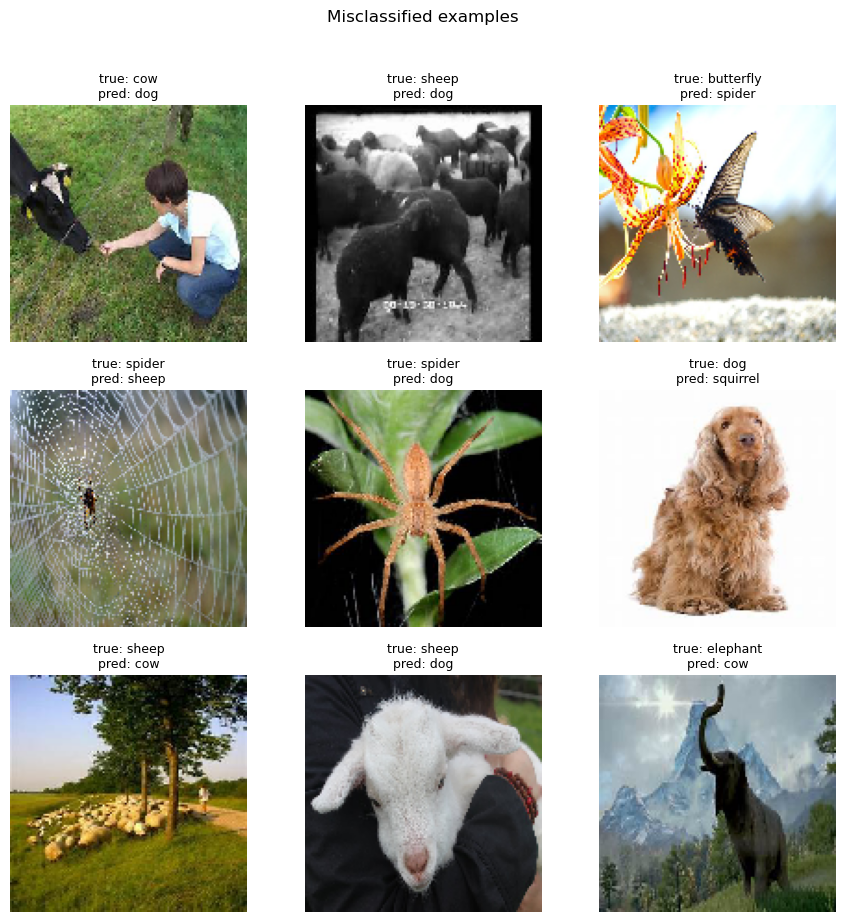

In [9]:
plot_misclassified(model, val_generator)

## 9. Record result to the tracking sheet

Upsert this model's validation row (accuracy, macro P/R/F1, measured LR and train
time, notes) into the shared `model_tracking.csv`. Re-running replaces the row.

In [10]:
learning_rate = round(float(model.optimizer.learning_rate.numpy()), 6)

row = evaluate_model(model, val_generator, "baseline_cnn")
row.update({
    "architecture": "3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5)",
    "learning_rate": learning_rate,
    "train_time_min": train_time_min,
    "notes": "Baseline (val metrics). Overfits (~13% train-val gap); biased to dog/spider.",
})
record_result(row)

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step


,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
0,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
1,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
2,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
3,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,FAILED to train: plain deep CNN collapsed to ~...
4,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...
5,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...


## 10. Save the model

Save only when freshly trained (a loaded model is already on disk), so
`model_final_test.ipynb` can reuse it without retraining.

In [11]:
# Persist freshly trained models; a loaded model is already saved.
if history is not None:
    os.makedirs("models_saved", exist_ok=True)
    model.save(MODEL_PATH)
    print(f"Saved {MODEL_PATH}")
else:
    print(f"Using existing {MODEL_PATH}")

Using existing models_saved/baseline_cnn.keras


## 11. Compare all models

Bar chart of validation accuracy across every model recorded so far, read
straight from the tracking sheet - the running scoreboard.

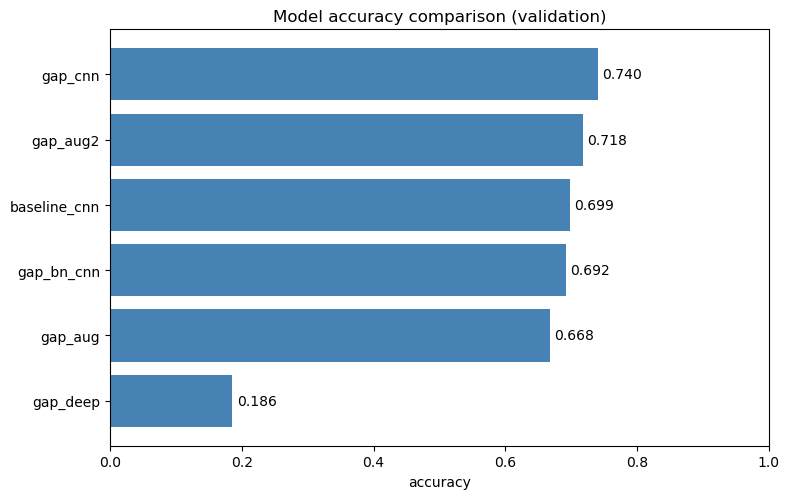

,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
3,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,FAILED to train: plain deep CNN collapsed to ~...
1,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
0,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
5,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
2,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
4,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...


In [12]:
from model_metrics import plot_accuracy_comparison

plot_accuracy_comparison()